In [1]:
!pip install --upgrade pip --quiet

In [2]:
!pip install --upgrade numpy pandas scipy --quiet

In [3]:
!pip install --upgrade statsmodels --quiet

In [4]:
!pip install --upgrade linearmodels --quiet

In [5]:
!pip install --upgrade matplotlib seaborn --quiet

In [6]:
import numpy as np

In [7]:
import pandas as pd

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [10]:
import statsmodels.formula.api as smf

In [11]:
from linearmodels import PanelOLS

In [12]:
def tabela_2x2(dados, tratamento, pos, outcome):
    """Tabela 2x2 da DiD canônica e cálculo manual."""
    g = (dados.groupby([pos, tratamento])[outcome].mean()
              .unstack().round(4))
    g.index = ["pré (2005)", "pós (2009)"]
    g.columns = ["controle", "tratado"]
    dif_trat = g.loc["pós (2009)", "tratado"] - g.loc["pré (2005)", "tratado"]
    dif_ctrl = g.loc["pós (2009)", "controle"] - g.loc["pré (2005)", "controle"]
    did = dif_trat - dif_ctrl
    return g, dif_trat, dif_ctrl, did

# Avaliação de Políticas Públicas com Dados 📊

<p style="text-align: right">Prof. <a href="https://www.linkedin.com/in/heliomacedofilho/">Hélio Bomfim de Macêdo Filho</a><br />
<a href="https://www.idp.edu.br/mestrado/profissional-em-ciencia-de-dados">Mestrado em Administração Pública:<br />Ciência de Dados e Inteligência Artificial no Setor Público</a></p>

## Módulo 04 — Diferenças-em-Diferenças (DiD)

## Sumário
<ul>
    <li>A intuição do DiD e o setup $2 \times 2$</li>
    <li>Tendências paralelas e a regressão equivalente</li>
    <li>TWFE: painel e efeitos fixos de duas vias</li>
    <li>Inferência: erros-padrão clusterizados</li>
    <li>O problema do TWFE escalonado (Goodman-Bacon)</li>
    <li>Extra! 🗞️ Soluções modernas (Callaway-Sant'Anna)</li>
    <li>Extra! 🗞️ Controle sintético</li>
</ul>

👉 Leitura de apoio desta aula (todas gratuitas online):

- CUNNINGHAM, S. *<a href="https://mixtape.scunning.com/09-difference_in_differences">Causal Inference: The Mixtape</a>*, cap. 9.
- HUNTINGTON-KLEIN, N. *<a href="https://theeffectbook.net/">The Effect</a>*, cap. 18.
- FACURE, M. *<a href="https://matheusfacure.github.io/python-causality-handbook/">Causal Inference for the Brave and True</a>*, caps. 13 e 14.
- ROTH, J. et al. (2023). *<a href="https://www.sciencedirect.com/science/article/abs/pii/S0304407623001318">What's trending in differences-in-differences?</a>*. *Journal of Econometrics*, 235(2).

🚨 **Antes de começar — arquivo de dados.** 🎲

Usaremos a Avaliação de Impacto do Bolsa Família (AIBF II), módulo de educação.

👉 Os microdados são públicos e desidentificados. Distribuídos pela 
- Secretaria de Avaliação, Gestão da Informação e Cadastro Único (Sagicad) do
- Ministério do Desenvolvimento e Assistência Social, Família e Combate à Fome (MDS). 

Fonte: <a href="https://aplicacoes.mds.gov.br/sagicad/pesquisas/lista-s.php?stk=ano&i=2012">Pesquisa de Avaliação de Impacto do Programa Bolsa Família (AIBF II)</a>

Especificamente, os arquivos
- `data/aula04_painel.csv`
    - (painel domiciliar 2005-2009 construído a partir da AIBF II — Avaliação de Impacto do Bolsa Família) e

## Recapitulando o Módulo 03 🔁

👉 Nas três primeiras aulas montamos a "escada" da inferência causal:

- **Módulo 01** — o problema:
    - a diferença simples mistura **efeito** com **viés de seleção**.
- **Módulo 02** — uma solução perfeita:
    - o **sorteio** zera o viés.
    - Mas o gestor quase nunca pode sortear.
- **Módulo 03** — uma solução para o gestor:
    - **seleção nos observáveis** — se controlarmos pelas covariáveis certas (ignorabilidade),
        - o viés vai a zero.

🚨 O Módulo 03 deixou um problema aberto: 
- a ignorabilidade exige que **todos** os confundidores estejam em `X`.

Se sobrar um confundidor não observado 
- e.g. motivação, capital social, expectativas,
- o método falha.

👉 e não há como verificar isso nos dados.

👉 A pergunta desta aula:

> Existe alguma forma de neutralizar **confundidores não observados**, desde que eles sejam **constantes no tempo**?

A resposta é sim — e ela vem com dados de **painel**.

## A intuição do DiD e o setup 2×2

### O Fio Condutor: a AIBF II (como painel) 🇧🇷

Voltamos à **AIBF II** 
- agora aproveitando que ela é um **painel**:
    - os mesmos domicílios entrevistados
        - em **2005** (linha de base) e
        - em **2009** (seguimento).

🚨 A pegadinha que já vimos:
- indivíduos não se ligam entre as rodadas;
- só **domicílios**. 

Por isso o painel é em nível domiciliar 
- desfechos agregados por casa.

👉 Vamos carregar os dados.

In [13]:
aibf = pd.read_csv("data/aula04_painel.csv")
aibf.shape

(19425, 19)

👉 Cada linha é um **domicílio em uma rodada**. 

In [14]:
aibf[["cod_dtm","ano","grupo","tratado","pos",
      "attend_med","dropout_med","grade_now_med"]].head()

,cod_dtm,ano,grupo,tratado,pos,attend_med,dropout_med,grade_now_med
0,1.0,2005,T1,1,0,1.0,NaN,NaN
1,3.0,2005,T1,1,0,0.5,0.5,5.000000
2,4.0,2005,T1,1,0,1.0,0.0,6.000000
3,7.0,2005,C2,0,0,1.0,0.0,4.333333
4,8.0,2005,C2,0,0,1.0,0.0,6.500000


Os mesmos domicílios aparecem em 2005 e 2009 (quando há crianças de 6-17 nas duas).

As variáveis-chave:

| Coluna | Papel | Significado |
|---|---|---|
| `cod_dtm` | identificador | id do domicílio |
| `ano` | tempo | 2005 ou 2009 |
| `grupo` | tipo | $T1$, $C1$ ou $C2$ (definição IFPRI) |
| `tratado` | tratamento | 1 se $T1$ (beneficiário em 2009) |
| `pos` | pós-tratamento | 1 se ano = 2009 |
| `attend_med` | desfecho | matrícula média das crianças do domicílio |
| `dropout_med` | desfecho | evasão média |
| `grade_now_med` | desfecho | série média atual |

ℹ️ A classificação **$T1$, $C1$, $C2$** vem do desenho do IFPRI (de Brauw et al.):

- **$T1$** — recebia Bolsa Família em 2009 (tratado);
- **$C1$** — inscrito no CadÚnico, mas **não** recebia BF (controle "cadastrado");
- **$C2$** — não inscrito no CadÚnico (controle "não-cadastrado").

👉 Como no Módulo 03, vamos usar **$T1$ vs $C1$** como comparação principal. 
- $C1$ é o controle mais defensável:
    - ambos passaram pelo mesmo filtro administrativo.

Mais adiante, usaremos $C2$ como **placebo**.

In [15]:
# Comparação principal: $T1$ (tratados) vs $C1$ (controle cadastrado)
dados = aibf[aibf["grupo"].isin(["T1","C1"])].copy()

In [16]:
pd.DataFrame({"domicílios T1": [(dados["grupo"]=="T1").sum()], 
              "domicílios C1": [(dados["grupo"]=="C1").sum()]})

,domicílios T1,domicílios C1
0,5879,4154


### A Diferença Simples (Outra Vez)

👉 Como sempre, começamos pela comparação ingênua: 
- tratados vs controles **em 2009**.

👉 Variável `attend_med`: 
- matrícula média das crianças do domicílio

In [17]:
ingenua = (dados[dados["ano"]==2009]
          .groupby("grupo")["attend_med"].mean())

In [18]:
print(ingenua.round(4).map(lambda x: f"{x:.2%}"))

grupo
C1    87.47%
T1    89.65%
Name: attend_med, dtype: str


In [19]:
print("Diferença (T1 - C1):",
      round(ingenua["T1"] - ingenua["C1"], 4))

Diferença (T1 - C1): 0.0218


ℹ️ A diferença em 2009 é pequena e positiva 
- beneficiários têm matrícula média ligeiramente maior.

Mas você já sabe o problema: 
- tratados e controles podem ter sido diferentes **antes** do programa também.

👉 Por isso, o DiD. 

Vamos olhar a **variação** do desfecho entre 2005 e 2009
- *o que cresceu/encolheu em cada grupo*.

### O setup $2 \times 2$ — quatro números que respondem a pergunta 👩🏽‍🏫

👉 A ideia central do DiD em uma frase:

> O efeito causal é a **diferença** entre quanto o desfecho mudou no grupo tratado e quanto mudou no grupo de controle.

Em quatro pontos, no caso da AIBF:

| | Pré (2005) | Pós (2009) |
|---|---|---|
| Tratados ($T1$) | $\bar Y_{T,pré}$ | $\bar Y_{T,pós}$ |
| Controle ($C1$) | $\bar Y_{C,pré}$ | $\bar Y_{C,pós}$ |

A fórmula DiD:

$$\widehat{\text{DiD}} = (\bar Y_{T,pós} - \bar Y_{T,pré}) - (\bar Y_{C,pós} - \bar Y_{C,pré})$$

👉 Vamos computar essa tabela $2 \times 2$ para a matrícula escolar.

In [20]:
g, dt, dc, did = tabela_2x2(dados, "tratado", "pos", "attend_med")
g.T.iloc[::-1]

,pré (2005),pós (2009)
tratado,0.9339,0.8965
controle,0.9209,0.8747


In [21]:
print(f"Variação no grupo tratado ($T1$):  {dt:+.4f}")

Variação no grupo tratado ($T1$):  -0.0374


In [22]:
print(f"Variação no grupo controle ($C1$): {dc:+.4f}")

Variação no grupo controle ($C1$): -0.0462


In [23]:
print(f"DiD = variação T - variação C  = {did:+.4f}")

DiD = variação T - variação C  = +0.0088


ℹ️ A matrícula **caiu** nos dois grupos entre 2005 e 2009 
- a coorte envelheceu, e
- adolescentes deixam mais a escola que crianças.

🚨 Mas ela caiu **menos** entre os beneficiários do Bolsa Família.

👉 A diferença das variações é o efeito causal estimado pelo DiD
- **+0,009 ponto percentual** sobre a probabilidade média de matrícula.

### Por que isso funciona?

Pense no que o DiD **elimina**:

1. Tudo que difere entre tratados e controles e é **constante no tempo**
    - e.g., motivação, capital social, traços culturais
    - entra nas duas linhas da tabela do mesmo modo, e
        - some na subtração.
2. Tudo que muda no tempo e afeta os **dois grupos por igual**
    - e.g., uma crise econômica, uma reforma educacional nacional
    - entra nas duas colunas do mesmo modo, e
        - também some.

🚨 O que sobra é a diferença que **não** se explica 
- nem por características permanentes
- nem por tendência comum

👉 atribuímos isso ao programa (BF).

👉 Compare com o Módulo 03: 
- lá controlávamos pelas covariáveis **observáveis**.
- aqui, controlamos por **toda característica não observada**
    - que seja constante no tempo. 

É um salto enorme 
- desde que a hipótese de fundo seja válida (e veremos qual é).

## Tendências paralelas e a regressão equivalente

### A hipótese-chave: tendências paralelas 📐

👉 O DiD não é mágica. 

Ele depende de **uma** hipótese, e ela é forte:

> Na ausência do tratamento, o grupo tratado teria seguido a **mesma tendência** do grupo de controle entre 2005 e 2009.

Em símbolos: $$E[Y_{T}(0)_{2009} - Y_{T}(0)_{2005}] = E[Y_{C}(0)_{2009} - Y_{C}(0)_{2005}]$$

🚨 Lê-se: 
- *se* o Bolsa Família não existisse,
- a matrícula nos domicílios
    - $T1$ teria caído **na mesma proporção**
    - que nos $C1$.

Toda diferença nas variações é atribuída ao programa.

👉 Esta é a **hipótese de tendências paralelas** (*parallel trends*). 
- É a gêmea da ignorabilidade do Módulo 03
    - só que agora referente a *tendências*, não a *níveis*.

🚨 **A hipótese não é testável.** 
- O lado esquerdo da igualdade contém um contrafactual
    - o que teria acontecido aos tratados sem o programa.

Esse número não existe nos dados.

ℹ️ O que se pode fazer é checar evidências indiretas: 
- pré-tendências (a trajetória do desfecho **antes** do tratamento),
- placebos, e
- testes de sensibilidade. 

Voltaremos a isso.

### Visualizando o DiD 📊

👉 O gráfico canônico do DiD 
- quatro pontos,
- duas linhas, e
- a **linha contrafactual** tracejada.

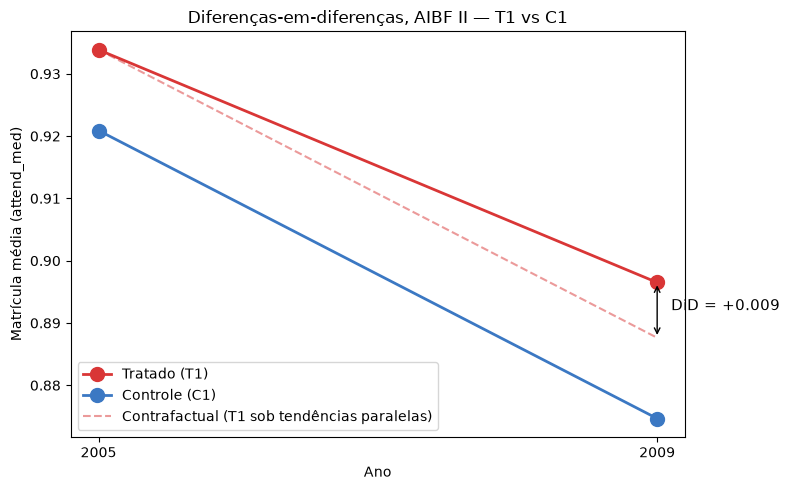

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

medias = dados.groupby(["ano","grupo"])["attend_med"].mean().unstack()

# linhas observadas
ax.plot(medias.index, medias["T1"], "o-", color="#d93636",
        label="Tratado (T1)", lw=2, markersize=10)
ax.plot(medias.index, medias["C1"], "o-", color="#3b78c3",
        label="Controle (C1)", lw=2, markersize=10)

# linha contrafactual: o que aconteceria com T1 se seguisse a tendência de C1
contraf_2009 = medias.loc[2005,"T1"] + (medias.loc[2009,"C1"] - medias.loc[2005,"C1"])
ax.plot([2005, 2009], [medias.loc[2005,"T1"], contraf_2009],
        "--", color="#d93636", alpha=0.5,
        label="Contrafactual (T1 sob tendências paralelas)")

# anotação do efeito
ax.annotate("", xy=(2009, medias.loc[2009,"T1"]),
            xytext=(2009, contraf_2009),
            arrowprops=dict(arrowstyle="<->", color="black"))
ax.text(2009.1, (medias.loc[2009,"T1"]+contraf_2009)/2,
        f"DiD = {medias.loc[2009,'T1']-contraf_2009:+.3f}", fontsize=11)

ax.set_xlabel("Ano")
ax.set_ylabel("Matrícula média (attend_med)")
ax.set_title("Diferenças-em-diferenças, AIBF II — T1 vs C1")
ax.set_xticks([2005, 2009])
ax.legend(loc="lower left")
plt.tight_layout();

ℹ️ Lê-se o gráfico assim: 
1. a linha vermelha tracejada é o que teria acontecido
    - com os tratados se eles tivessem seguido
    - a tendência do controle (i.e. **o contrafactual**).
2. A diferença entre a linha cheia vermelha e a tracejada em 2009 é o efeito estimado.

### A mesma DiD via regressão

👉 Os mesmos quatro números podem ser obtidos por uma regressão com uma **interação**:

$$Y_{it} = \alpha + \beta\,\text{tratado}_i + \gamma\,\text{pos}_t + \delta\,(\text{tratado}_i \times \text{pos}_t) + \varepsilon_{it}$$

O coeficiente da interação ($\delta$) é exatamente a DiD.

In [25]:
def did_ols(dados, outcome, cluster_col="cod_dtm"):
    """Estima DiD por regressão com interação, c/ erros clusterizados."""
    d = dados.dropna(subset=[outcome])
    formula = f"{outcome} ~ tratado + pos + tratado:pos"
    return smf.ols(formula, data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d[cluster_col].values})

In [26]:
m = did_ols(dados, "attend_med")

In [27]:
print(m.summary().tables[1])

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.9209      0.005    190.288      0.000       0.911       0.930
tratado         0.0130      0.006      2.174      0.030       0.001       0.025
pos            -0.0462      0.009     -5.373      0.000      -0.063      -0.029
tratado:pos     0.0089      0.011      0.830      0.407      -0.012       0.030


In [28]:
print(f"DiD (coef da interação): {m.params['tratado:pos']:+.4f}")

DiD (coef da interação): +0.0089


In [29]:
print(f"Confere com 2x2 manual:  {did:+.4f}")

Confere com 2x2 manual:  +0.0088


ℹ️ Os dois números batem.

A regressão e a "fórmula do quadradinho" são equivalentes 
- mas a regressão é mais flexível:
    - permite covariáveis,
    - desfechos múltiplos, e
    - (como veremos) erros-padrão clusterizados.

🚨 Repare o `cov_type="cluster"` em `did_ols`. 

Como cada domicílio aparece duas vezes no painel, 
- suas observações não são independentes

voltaremos a isso no bloco de inferência.

### Os três desfechos

👉 Vamos rodar o DiD nos três desfechos da AIBF de uma vez.

In [30]:
resultados = []
for outcome, descricao in [("attend_med", "Matrícula"),
                            ("dropout_med", "Evasão"),
                            ("grade_now_med", "Série atual")]:
    
    _, dt, dc, did = tabela_2x2(dados, "tratado", "pos", outcome)
    
    m_loop = did_ols(dados, outcome)
    resultados.append({
        "desfecho": descricao,
        r"($\bar Y_{T,pós} - \bar Y_{T,pré})$": dt,
        r"$(\bar Y_{C,pós} - \bar Y_{C,pré})$": dc,
        "DiD (2x2)": did,
        "DiD (RL)": m_loop.params["tratado:pos"],
        "std err": m_loop.bse["tratado:pos"],
        "p-valor": m_loop.pvalues["tratado:pos"],
    })

In [31]:
pd.DataFrame(resultados).round(4)

,desfecho,"($\bar Y_{T,pós} - \bar Y_{T,pré})$","$(\bar Y_{C,pós} - \bar Y_{C,pré})$",DiD (2x2),DiD (RL),std err,p-valor
0,Matrícula,-0.0374,-0.0462,0.0088,0.0089,0.0107,0.4067
1,Evasão,0.0461,0.0541,-0.0080,-0.0080,0.0094,0.3933
2,Série atual,0.5172,0.3645,0.1527,0.1527,0.1038,0.1413


ℹ️ Lendo os três desfechos:

- A **matrícula** dos tratados caiu **menos** que a do controle (+0,009);
- A **evasão** subiu **menos** nos tratados (−0,008);
- A **série** progrediu **mais** nos tratados (+0,15).

🚨 Os três efeitos vão na **direção correta**, 
- mas nenhum é estatisticamente significativo a 5%
- (todos os $p$-valores > 0,10). 

Isso é uma realidade da literatura:
- de Brauw et al. (2015) encontraram efeitos positivos pequenos,
    - significativos só em subgrupos (meninas, área rural).

👉 A lição é honesta: efeitos modestos, com incerteza considerável 
- o que é diferente de "o programa não funciona". 

🚨 Sinal pequeno num painel ruidoso não prova ausência de efeito.

## Wrap-Up

👉 Até aqui: a intuição do DiD, a hipótese central, e a regressão equivalente.

Na volta: 
- o **TWFE** (*Two-Way Fixed Effect*/efeitos fixos de duas vias)
    - que generaliza o DiD para
        - múltiplos períodos e
        - múltiplos grupos
- depois, um problema sério que esse estimador esconde
    - quando o tratamento é **escalonado**.

## TWFE: painel e efeitos fixos de duas vias

👉 A regressão do bloco anterior funciona para **dois grupos $\times$ dois períodos**. 

A vida real raramente é tão limpa: pode haver
- muitos períodos,
- muitos grupos,
- tratamento que entra em momentos diferentes para cada um.

A generalização canônica é 
- a regressão com **efeitos fixos de duas vias** (*two-way fixed effects*, TWFE):

$$Y_{it} = \alpha_i + \gamma_t + \delta\,D_{it} + \varepsilon_{it}$$

ℹ️ Os componentes:

- $\alpha_i$ é um **efeito fixo por unidade** (domicílio)
    - absorve tudo que é constante no tempo dentro daquela unidade.
    - É a generalização do "tratado" da regressão 2×2.
- $\gamma_t$ é um **efeito fixo por período** (ano)
    - absorve tudo que afeta todos no mesmo período.
    - É a generalização do "pos".
- $D_{it}$ é o tratamento ($=1$ quando $i$ está tratado em $t$).
- $\delta$ é o coeficiente de interesse.

🚨 Com dois grupos e dois períodos, 
- o TWFE devolve **exatamente** a mesma DiD que a regressão com interação.

Vamos confirmar.

In [32]:
# Restringir aos domicílios com painel COMPLETO 
# (aparecem em 2005 e 2009)
dados_painel = dados.dropna(subset=["attend_med"]).copy()
rodadas = dados_painel.groupby("cod_dtm")["ano"].nunique()
dom_completos = rodadas[rodadas == 2].index
dados_painel = dados_painel[dados_painel["cod_dtm"].isin(dom_completos)]

In [33]:
print("domicílios c/ painel completo:", dados_painel["cod_dtm"].nunique())

domicílios c/ painel completo: 3419


In [34]:
print("linhas:", len(dados_painel))

linhas: 6838


In [35]:
# linearmodels exige MultiIndex (unidade, tempo)
dados_painel = dados_painel.set_index(["cod_dtm", "ano"])
dados_painel["D"] = dados_painel["tratado"] * dados_painel["pos"]

In [36]:
twfe = PanelOLS(dados_painel["attend_med"], dados_painel[["D"]],
                entity_effects=True, time_effects=True)

twfe = twfe.fit(cov_type="clustered", cluster_entity=True)

In [37]:
twfe

Dep. Variable:,attend_med,R-squared:,0.0002
Estimator:,PanelOLS,R-squared (Between):,0.0054
No. Observations:,6838,R-squared (Within):,-0.0050
Date:,"Thu, Aug 20 2026",R-squared (Overall):,0.0051
Time:,19:23:05,Log-likelihood,2942.5
Cov. Estimator:,Clustered,,
,,F-statistic:,0.5691
Entities:,3419,P-value,0.4507
Avg Obs:,2.0000,Distribution:,"F(1,3417)"
Min Obs:,2.0000,,
Max Obs:,2.0000,F-statistic (robust):,0.2721


In [38]:
print(f"""TWFE
    coef D: {twfe.params['D']:+.4f};
    SE: {twfe.std_errors['D']:.4f}.""")

TWFE
    coef D: +0.0083;
    SE: 0.0160.


In [39]:
print(f"""DiD (OLS) 
    coef D: {m.params['tratado:pos']:+.4f};
    SE: {m.bse['tratado:pos']:.4f}.""")

DiD (OLS) 
    coef D: +0.0089;
    SE: 0.0107.


ℹ️ Os dois batem 
- (pequenas diferenças vêm
    - do filtro de painel completo e
    - do tratamento de valores ausentes).

O TWFE é apenas a regressão $2 \times 2$ escrita de modo mais geral.

🚨 A vantagem do TWFE aparece quando 
- há **mais de dois períodos** ou
- **tratamento que entra em momentos diferentes** (escalonado).

Vamos ver isso no Bloco 5 
- e o problema escondido que essa generalização traz.

## Inferência: erros-padrão clusterizados

### Por que clusterizar

👉 Cada domicílio aparece **duas vezes** no nosso painel 
- 2005 e 2009.

As duas observações não são independentes: vêm 
- da mesma família,
- com os mesmos pais,
- no mesmo bairro.

Se ignoramos isso, 
- o erro-padrão fica **pequeno demais** e 
    - (a estimativa parece mais precisa do que é)
- os $p$-valores ficam **otimistas demais**
    - (vemos "efeitos significativos" que são só ruído).

🚨 Bertrand, Duflo & Mullainathan (2004) mostraram que
- ignorar correlação serial em DiD pode
    - gerar **até $45\%$ de falsos-positivos** num teste nominal de $5\%$.

A solução padrão: 
- **erros-padrão clusterizados** pela unidade
    - agrupando as observações do mesmo domicílio.

👉 Vamos comparar os dois cálculos.

In [40]:
d_clean = dados.dropna(subset=["attend_med"]).copy()

In [41]:
# erro-padrão "ingênuo" (sem cluster)
m_ing = smf.ols("attend_med ~ tratado + pos + tratado:pos",
                data=d_clean).fit()

In [42]:
m_ing.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             attend_med   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     25.90
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.11e-16
Time:                        19:23:05   Log-Likelihood:                -139.58
No. Observations:                9804   AIC:                             287.2
Df Residuals:                    9800   BIC:                             315.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.9209      0.005    183.082      0.000       0.911       0.931
tratado         0.0130      0.007      1.974      0.048    9.12e-05       0.026
pos            -0.0462      0.008     -5.884      0.000      -0.062      -0.031
tratado:pos     0.0089      0.010      0.867      0.386      -0.011       0.029
==============================================================================
Omnibus:                     5615.345   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34304.782
Skew:                          -2.856   Prob(JB):                         0.00
Kurtosis:                      10.166   Cond. No.                         7.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
# erro-padrão clusterizado por domicílio
m_clu = smf.ols("attend_med ~ tratado + pos + tratado:pos",
                data=d_clean).fit(cov_type="cluster",
                                  cov_kwds={"groups": d_clean["cod_dtm"].values})

In [44]:
m_clu.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             attend_med   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     24.28
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.29e-15
Time:                        19:23:05   Log-Likelihood:                -139.58
No. Observations:                9804   AIC:                             287.2
Df Residuals:                    9800   BIC:                             315.9
Df Model:                           3                                         
Covariance Type:              cluster                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.9209      0.005    190.288      0.000       0.911       0.930
tratado         0.0130      0.006      2.174      0.030       0.001       0.025
pos            -0.0462      0.009     -5.373      0.000      -0.063      -0.029
tratado:pos     0.0089      0.011      0.830      0.407      -0.012       0.030
==============================================================================
Omnibus:                     5615.345   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34304.782
Skew:                          -2.856   Prob(JB):                         0.00
Kurtosis:                      10.166   Cond. No.                         7.09
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [45]:
pd.DataFrame({
    "erro-padrão": ["ingênuo (sem cluster)", "clusterizado por domicílio"],
    "valor": [m_ing.bse["tratado:pos"], m_clu.bse["tratado:pos"]],
}).round(4)

,erro-padrão,valor
0,ingênuo (sem cluster),0.0102
1,clusterizado por domicílio,0.0107


ℹ️ O erro-padrão clusterizado é **maior** que o ingênuo
- a estimativa de fato é menos precisa do que a versão ingênua sugere.

É a mesma lição do Módulo 02, agora aplicada ao painel:
- respeite a estrutura de dependência dos dados.

### O teste placebo: $C1$ vs $C2$

👉 Outro diagnóstico clássico em DiD: 
- rodar a mesma análise **entre dois grupos de controle**.

Se o método é confiável, 
- não deve aparecer "efeito" algum aí,
- pois não há tratamento.

In [46]:
placebo = aibf[aibf["grupo"].isin(["C1", "C2"])].copy()
placebo["t_placebo"] = (placebo["grupo"] == "C1").astype(int)

In [47]:
m_plac = smf.ols("attend_med ~ t_placebo + pos + t_placebo:pos",
                 data=placebo.dropna(subset=["attend_med"])).fit(
    cov_type="cluster",
    cov_kwds={"groups": placebo.dropna(subset=["attend_med"])["cod_dtm"].values})

In [48]:
print(f"Placebo DiD ($C1$ vs C2): {m_plac.params['t_placebo:pos']:+.4f}")

Placebo DiD ($C1$ vs C2): -0.0010


In [49]:
print(f"p-valor: {m_plac.pvalues['t_placebo:pos']:.3f}")

p-valor: 0.924


ℹ️ O placebo dá **quase exatamente zero**, 
- com $p$-valor altíssimo. 

É o resultado ideal: 
- o método não "vê" efeito onde não há.

🚨 Se o placebo tivesse dado um número grande, 
- seria um sinal de alerta:
    - as tendências paralelas talvez não valessem nem entre os controles, e
    - o efeito estimado entre $T1$ e $C1$ ficaria suspeito.

## O problema do TWFE escalonado (Goodman-Bacon)

👉 O TWFE parece resolver tudo 
- mas há um problema sério que ele esconde,
- descoberto por **Andrew Goodman-Bacon (2021)**.

O problema só aparece quando o tratamento é **escalonado** (*staggered adoption*): 
- grupos que recebem o tratamento em **momentos diferentes**.

ℹ️ A AIBF tem só dois períodos (2005, 2009), então 
- o problema não aparece aqui. 

O **setup escalonado** é o cenário típico em avaliação: 
- imagine que o BF foi implementado **município a município** ao longo de vários anos
    - alguns entraram em 2004,
    - outros em 2007,
    - outros em 2011. 

### O que Goodman-Bacon descobriu

👉 Goodman-Bacon mostrou que 
- o coeficiente do TWFE é uma **média ponderada**
    - de comparações $2 \times 2$
    - entre todos os pares de grupos no painel.

Algumas dessas comparações são **boas**: comparam 
- um grupo recém-tratado com
- um nunca-tratado. 

Outras são **problemáticas**: comparam
- um grupo tratado *depois* usando
- um grupo tratado *antes* como "controle".

🚨 Quando há efeitos **heterogêneos no tempo** (o efeito do programa muda ao longo dos anos), 
- essas comparações problemáticas
    - geram **viés**
    - que pode levar o TWFE a errar feio.

Em casos extremos, 
- o sinal estimado pode até ser o oposto da verdade.

### Demonstrando o problema com simulação 🧪

👉 Vamos simular um cenário 
- onde **conhecemos a verdade** e
- veremos o TWFE falhar.

Cenário: 300 unidades em 10 períodos.
- 100 unidades tratadas **cedo** (t=3),
    - com efeito **+2,0**;
- 100 unidades tratadas **tarde** (t=7),
    - com efeito **+5,0**
    - (maior — efeito heterogêneo).
- 100 unidades
    - **nunca** tratadas.

In [50]:
np.random.seed(42)
N, T = 300, 10
linhas = []
for i in range(N):
    if i < 100:
        grupo, t_inicio, efeito = "cedo", 3, 2.0
    elif i < 200:
        grupo, t_inicio, efeito = "tarde", 7, 5.0
    else:
        grupo, t_inicio, efeito = "nunca", np.nan, 0.0
    for t in range(T):
        D = int(t >= t_inicio) if grupo != "nunca" else 0
        Y = i*0.1 + t*0.05 + D*efeito + np.random.normal(0, 0.5)
        linhas.append({"unidade": i, "t": t, "t_inicio": t_inicio, "D": D, "Y": Y, "grupo": grupo})

sim = pd.DataFrame(linhas)

In [51]:
sim.head()

,unidade,t,t_inicio,D,Y,grupo
0,0,0,3.0,0,0.248357,cedo
1,0,1,3.0,0,-0.019132,cedo
2,0,2,3.0,0,0.423844,cedo
3,0,3,3.0,1,2.911515,cedo
4,0,4,3.0,1,2.082923,cedo


👉 Qual é o **ATT verdadeiro** (média do efeito entre os tratados)?

In [52]:
# cedo:  100 unidades × (10-3)=7 períodos × efeito 2.0
# tarde: 100 unidades × (10-7)=3 períodos × efeito 5.0

verdade = (100*7*2.0 + 100*3*5.0) / (100*7 + 100*3)

In [53]:
print(f"ATT verdadeiro: {verdade:.2f}")

ATT verdadeiro: 2.90


👉 Agora estimamos o TWFE.

In [54]:
sim_p = sim.set_index(["unidade", "t"])
twfe_sim = PanelOLS(sim_p["Y"], sim_p[["D"]],
                    entity_effects=True, time_effects=True).fit()

In [55]:
print(f"TWFE estimado:  {twfe_sim.params['D']:.2f}")

TWFE estimado:  3.57


In [56]:
print(f"ATT verdadeiro: {verdade:.2f}")

ATT verdadeiro: 2.90


In [57]:
print(f"Viés do TWFE:   {twfe_sim.params['D']-verdade:+.2f}")

Viés do TWFE:   +0.67


🚨 O TWFE **erra** 
- superestima o efeito em quase um ponto inteiro. 

Em dados reais, sem conhecer a verdade, 
- essa estimativa seria aceita como o "efeito do programa".

ℹ️ A intuição do erro: 
- o grupo "cedo" (já tratado em t=7)
    - é usado como "controle" para o grupo "tarde", mas
    - já está sob o efeito do tratamento naquele momento 
        - então as variações dele estão contaminadas.

O TWFE não enxerga essa contaminação; 
- ele apenas calcula a média ponderada mecanicamente.

👉 A descoberta de Goodman-Bacon abalou a literatura aplicada de economia entre 2018 e 2021. 

Centenas de *papers* publicados com TWFE em contextos escalonados precisaram ser reavaliados. 

A "revolução do DiD" 
- gerou uma família de **novos estimadores** que resolvem o problema 

👉 Assunto da próxima seção.

## Extra! 🗞️ Soluções modernas (Callaway-Sant'Anna)

👉 A geração pós-2020 de estimadores DiD tem várias propostas, 
- mas elas compartilham uma ideia comum:

> Em vez de uma média ponderada *opaca* de todas as comparações $2 \times 2$ (o que o TWFE faz),
> - **calcule explicitamente** o ATT para cada combinação de *coorte de tratamento* × *período*, e
> - depois agregue de forma transparente.

ℹ️ Os principais estimadores modernos:

- **Callaway & Sant'Anna (2021)**
    - *group-time ATT*:
        - estima $ATT(g, t)$
            - para cada coorte $g$ e
            - período $t$,
        - usando apenas comparações "limpas"
            - (com grupos nunca-tratados ou ainda-não-tratados como controle).
    - Pacotes
        - `did` em R,
        - `differences` em Python.

- **Sun & Abraham (2021)**
    - focado em *event studies*
        - (gráfico do efeito ao longo dos períodos relativos ao tratamento).
- **de Chaisemartin & D'Haultfœuille (2020)**
    - para tratamento que
        - **liga e desliga** ao longo do tempo.
- **Borusyak, Jaravel & Spiess (2024)**
    - *imputation estimator*:
        - imputa o contrafactual de cada tratado a partir do modelo nos não-tratados.

🚨 Recomendação prática (Roth et al. 2023):

- Tratamento em **um único período**,
    - dois grupos $\Rightarrow$ DiD/TWFE clássico ✅
- Tratamento **escalonado**,
    - efeitos possivelmente heterogêneos $\Rightarrow$ **Callaway-Sant'Anna**
        - (default razoável atual.)
- Quer **event study**
    - com pré-tendências bem comportadas $\Rightarrow$ **Sun-Abraham**

👉 Em Python, o pacote `differences` implementa Callaway-Sant'Anna com sintaxe próxima ao `linearmodels`:

In [58]:
!pip install --upgrade differences --quiet

ℹ️ Como a AIBF II tem só dois períodos, 
- esses estimadores reduzem ao DiD clássico aqui.

In [59]:
dados_painel = dados_painel.reset_index()
t_inicio = dados_painel[dados_painel["tratado"] == 1].\
    groupby("cod_dtm")["ano"].min()+1
dados_painel["t_inicio"] = dados_painel["cod_dtm"].map(t_inicio)
dados_painel = dados_painel.set_index(['cod_dtm', 'ano'])

In [60]:
from differences import ATTgt

att = ATTgt(data=dados_painel, cohort_column="t_inicio", 
            base_period="varying").fit(formula="attend_med")

Computing ATTgt [workers=1]   100%|████████████████████| 1/1 [00:00<00:00, 93.77it/s]


In [61]:
cs = att.aggregate("simple")  # ATT médio
cs

SimpleAggregation                                                          
                     analytic pointwise conf. band                           
                ATT std_error                lower    upper zero_not_in_cband
0          0.008328  0.011287            -0.013794  0.03045

In [62]:
print(f"""Callaway-Sant'Anna
    coef D: {cs.loc[0, ('SimpleAggregation', '', 'ATT')]:+.4f};
    SE: {cs.loc[0, ('SimpleAggregation', 'analytic', 'std_error')]:.4f}.""")

Callaway-Sant'Anna
    coef D: +0.0083;
    SE: 0.0113.


In [63]:
print(f"""TWFE
    coef D: {twfe.params['D']:+.4f};
    SE: {twfe.std_errors['D']:.4f}.""")

TWFE
    coef D: +0.0083;
    SE: 0.0160.


In [64]:
print(f"""DiD (OLS) 
    coef D: {m.params['tratado:pos']:+.4f};
    SE: {m.bse['tratado:pos']:.4f}.""")

DiD (OLS) 
    coef D: +0.0089;
    SE: 0.0107.


ℹ️ Os três batem 
- (pequenas diferenças vêm
    - do filtro de painel completo e
    - do tratamento de valores ausentes).

Também valem para o seu próximo trabalho de avaliação
- quando você for trabalhar com painel longo e
- tratamento escalonado.

In [65]:
from differences import ATTgt

att = ATTgt(data=sim_p, cohort_column="t_inicio", 
            base_period="varying").fit(formula="Y")

Computing ATTgt [workers=1]   100%|████████████████████| 18/18 [00:00<00:00, 341.67it/s]


In [66]:
cs = att.aggregate("simple")  # ATT médio
cs

SimpleAggregation                                                           
                     analytic pointwise conf. band                            
                ATT std_error                lower     upper zero_not_in_cband
0          2.952742  0.106369             2.744263  3.161222                 *

In [67]:
print(f"""Callaway-Sant'Anna
    coef D: {cs.loc[0, ('SimpleAggregation', '', 'ATT')]:+.4f};
    SE: {cs.loc[0, ('SimpleAggregation', 'analytic', 'std_error')]:.4f}.""")

Callaway-Sant'Anna
    coef D: +2.9527;
    SE: 0.1064.


In [68]:
print(f"TWFE estimado:  {twfe_sim.params['D']:.2f}")

TWFE estimado:  3.57


In [69]:
print(f"ATT verdadeiro: {verdade:.2f}")

ATT verdadeiro: 2.90


ℹ️ Apenas Callaway-Sant'Anna bate com valor verdadeiro.
- (🚨 O TWFE erra superestimando o efeito.).

## Extra! 🗞️ Controle sintético

👉 O **controle sintético** (Abadie, Diamond & Hainmueller, 2010) 
- é um primo do DiD para um caso particular:
    - quando há **uma única unidade tratada**
        - (e.g., uma cidade, um país, uma empresa)
    - e você precisa construir o contrafactual.

A ideia: 
- em vez de comparar com *uma* unidade de controle,
- construa um "controle sintético"
    - como **combinação ponderada** de várias unidades de controle,
- escolhendo os pesos para que o sintético **case com o tratado no pré-tratamento**.

ℹ️ O exemplo canônico é a Proposição 99 da Califórnia (1988) 
- uma lei de controle de tabagismo.

Abadie et al. construíram uma "Califórnia sintética" 
- como combinação de outros estados americanos, e
- mostraram que as vendas de cigarros caíram cerca de
    - **26 maços per capita por ano**
    - abaixo desse contrafactual sintético até 2000.

🚨 Não se aplica à AIBF (temos muitos tratados, não um),
- mas é a ferramenta certa para avaliar políticas
    - como uma reforma estadual,
    - uma intervenção municipal isolada,
    - etc.

👉 Em Python: 
- pacote `pysyncon` ou
- `SyntheticControlMethods`.

## Limitações e Próximo Módulo 🎯

👉 O que levamos deste módulo:

- O **DiD** estima o efeito causal
    - comparando a *variação* do desfecho entre tratados e controles,
    - eliminando confundidores não observados **constantes no tempo**.
- A hipótese-chave é **tendências paralelas**
    - não testável diretamente,
    - mas defensável com
        - pré-tendências,
        - placebos e
        - sensibilidade.

- A regressão com **interação** e o **TWFE** generalizam o DiD $2 \times 2$
    - mas exigem **erros-padrão clusterizados**.
- Em tratamento **escalonado** com efeitos heterogêneos,
    - o TWFE **falha**;
    - use os estimadores modernos (Callaway-Sant'Anna).
- Para **uma única unidade tratada**,
    - use **controle sintético**.

🚨 **As limitações do DiD.** Mesmo o DiD bem-feito não resolve:
- **Choques específicos de grupo** que coincidem com o tratamento
    - (e.g., uma seca atingiu desproporcionalmente os municípios beneficiados).
- **Antecipação** (*anticipation effects*)
    - se os tratados mudam o comportamento *antes* do tratamento por sabê-lo iminente,
    - a pré-tendência fica contaminada.
- **Spillovers**
    - quando o tratamento de uns afeta o desfecho de outros
    - (violação de SUTVA no tempo ou no espaço).
- **Mudança de composição**
    - se o painel não é balanceado e
    - quem sai/entra da amostra difere entre grupos.

👉 Uma **árvore de decisão** simplificada para você levar:

| Situação | Estimador |
|---|---|
| RCT bem desenhado | Módulo 02 |
| Ignorabilidade defensável dado X | PSM/IPW (Módulo 03) |
| Painel, tendências paralelas defensáveis, único momento de tratamento | **DiD/TWFE clássico** $\Leftarrow$ este Módulo |
| Painel com tratamento escalonado e efeitos heterogêneos | Callaway-Sant'Anna |
| Uma única unidade tratada agregada | Controle sintético |
| *Cutoff* arbitrário numa variável contínua | Regressão descontínua (Módulo 05) |

👉 **Para casa.**

1. Refaça
    - o DiD canônico ($T1$ vs $C1$)
        - para os outros dois desfechos (`dropout_med`, `grade_now_med`) e
        - calculando a tabela 2×2 manualmente.
2. Confirme que bate com a regressão.
3. Repita o **placebo** $C1$ vs $C2$ para os três desfechos.
    - Algum dá um número suspeito?
4. Estime o DiD
    - restringindo aos **domicílios com painel completo** (que aparecem em 2005 e 2009).
        - O efeito muda?
        - Por quê?

#### Saiba Mais 👩‍🏫

👉 Para se aprofundar em DiD:

- HUNTINGTON-KLEIN, N. *The Effect*, cap. 18 (intuição).
  <a href="https://theeffectbook.net/ch-DifferenceinDifference.html">link</a>
- CUNNINGHAM, S. *Causal Inference: The Mixtape*, cap. 9 (formalização).
  <a href="https://mixtape.scunning.com/09-difference_in_differences">link</a>
- FACURE, M. *Causal Inference for the Brave and True*, caps. 13-14 (Python).
  <a href="https://matheusfacure.github.io/python-causality-handbook/">link</a>
- ROTH, J. et al. (2023). What's trending in differences-in-differences?
  *Journal of Econometrics*, 235(2). — síntese da literatura moderna.

👉 **Executem todo este caderno** antes da próxima aula e tragam dúvidas. 🚀